In [ ]:
!pip install -q "kagglehub[pandas-datasets]"

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/sms-spam-collection-dataset",
    "spam.csv",
    pandas_kwargs={
        "encoding": "latin-1"
    }
)

print(df.head())
print(df.shape)

/tmp/ipykernel_659/1571271682.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)


DATA ANALYSIS


In [ ]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df=df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [ ]:
df.sample(5)

,v1,v2
4303,ham,"Good good, billy mates all gone. Just been jog..."
1749,ham,DO NOT B LATE LOVE MUM
2669,spam,we tried to contact you re your response to ou...
327,ham,"I'd say that's a good sign but, well, you know..."
1227,ham,So Ì_'ll be submitting da project tmr rite?


In [ ]:
df.shape

(5572, 2)

In [ ]:
df.isnull().sum()

,0
v1,0
v2,0


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df = df.drop_duplicates(keep='first')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df['v1'])
df['v1'] = le.transform(df['v1'])

print(le.classes_)

['ham' 'spam']


ham(not spam) is encoded to 0 and spam is encoded to 1

In [ ]:
df['v1'].value_counts()

,count
v1,
0,4516
1,653


DATA VISUALIZATION and TOKENIZATION



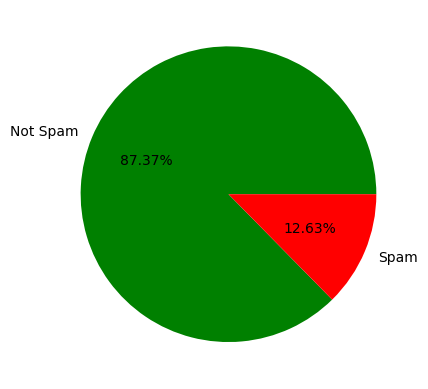

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['v1'].value_counts(), labels=['Not Spam','Spam'], autopct="%.2f%%", colors=['green','red'])
plt.show()

In [ ]:
import nltk
!pip install nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Tokenization using NLTK


df['char']=df['v2'].apply(lambda x: len(x))
df['num_digits'] = df['v2'].apply(
    lambda x: sum(c.isdigit() for c in x)
)
df['num_special_chars'] = df['v2'].apply(
    lambda x: sum(not c.isalnum() and not c.isspace() for c in x)
)
df['num_words']=df['v2'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sent']=df['v2'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [ ]:
df[['num_words',	'num_sent'	,'char','num_special_chars','num_digits']].describe()

,num_words,num_sent,char,num_special_chars,num_digits
count,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000
mean,18.455794,1.965564,78.977945,4.165603,2.205069
std,13.324758,1.448541,58.236293,4.477762,6.025241
min,1.000000,1.000000,2.000000,0.000000,0.000000
25%,9.000000,1.000000,36.000000,2.000000,0.000000
50%,15.000000,1.000000,60.000000,3.000000,0.000000
75%,26.000000,2.000000,117.000000,6.000000,1.000000
max,220.000000,38.000000,910.000000,133.000000,47.000000


In [ ]:
df[df['v1']==0][['num_words',	'num_sent'	,'char','num_special_chars','num_digits']].describe()

,num_words,num_sent,char,num_special_chars,num_digits
count,4516.000000,4516.000000,4516.000000,4516.000000,4516.000000
mean,17.123782,1.820195,70.459256,3.891275,0.290301
std,13.493970,1.383657,56.358207,4.531656,1.011825
min,1.000000,1.000000,2.000000,0.000000,0.000000
25%,8.000000,1.000000,34.000000,1.000000,0.000000
50%,13.000000,1.000000,52.000000,3.000000,0.000000
75%,22.000000,2.000000,90.000000,5.000000,0.000000
max,220.000000,38.000000,910.000000,133.000000,23.000000


In [ ]:
df[df['v1']==1][['num_words',	'num_sent'	,'char','num_special_chars','num_digits']].describe()

,num_words,num_sent,char,num_special_chars,num_digits
count,653.000000,653.000000,653.000000,653.000000,653.000000
mean,27.667688,2.970904,137.891271,6.062787,15.447167
std,7.008418,1.488425,30.137753,3.548616,8.924653
min,2.000000,1.000000,13.000000,0.000000,0.000000
25%,25.000000,2.000000,132.000000,3.000000,9.000000
50%,29.000000,3.000000,149.000000,6.000000,16.000000
75%,32.000000,4.000000,157.000000,8.000000,22.000000
max,46.000000,9.000000,224.000000,26.000000,47.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

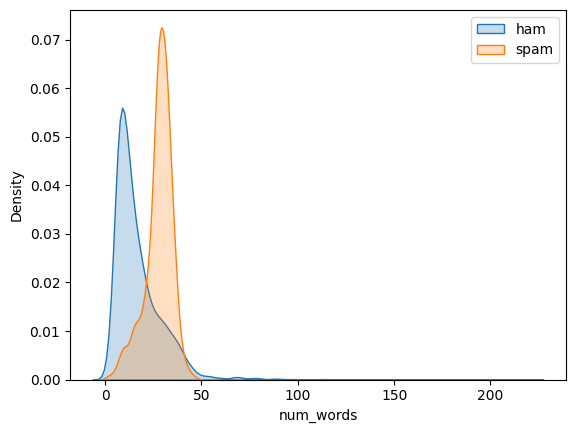

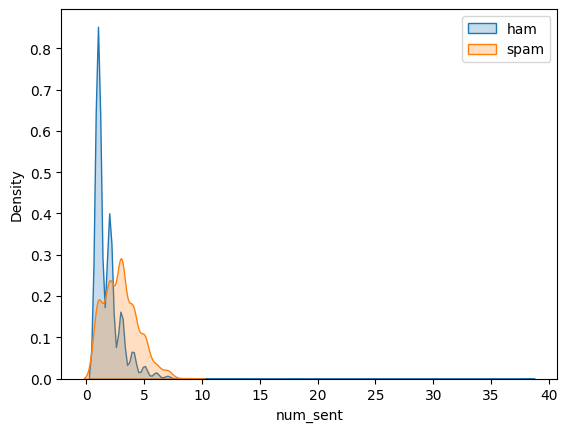

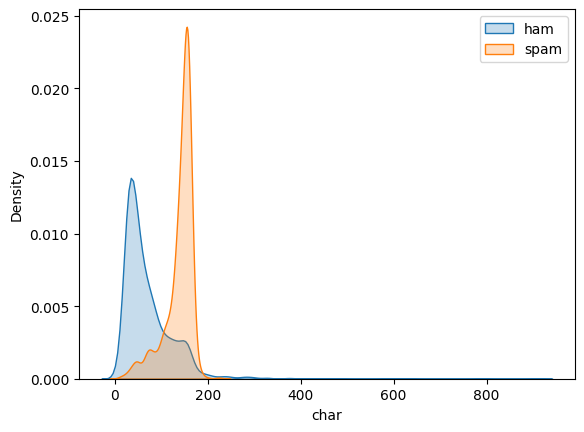

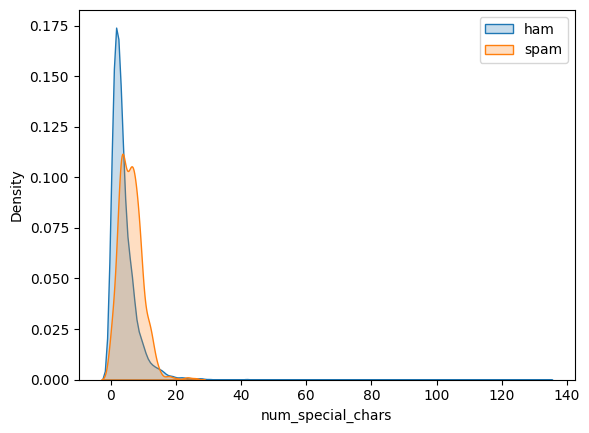

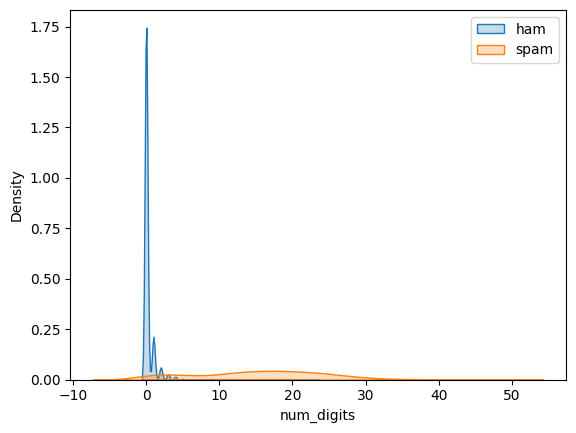

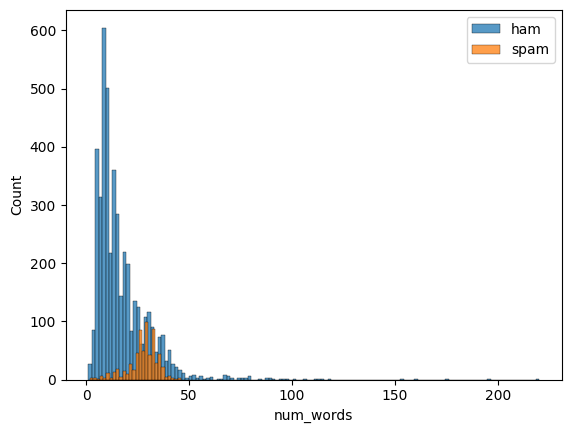

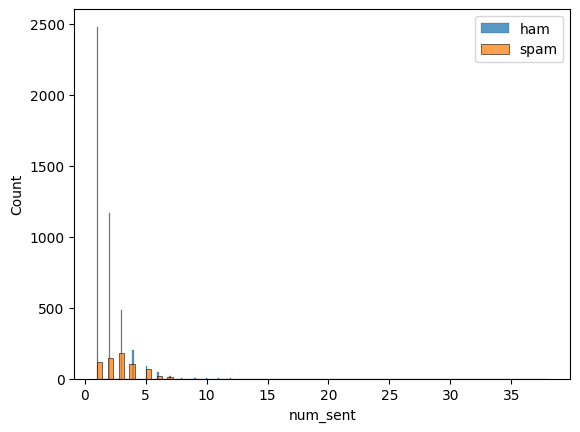

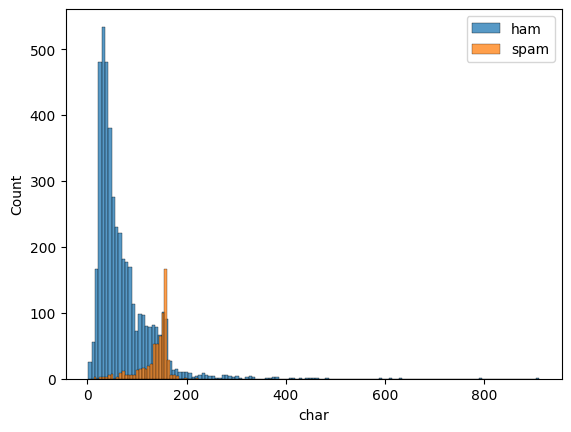

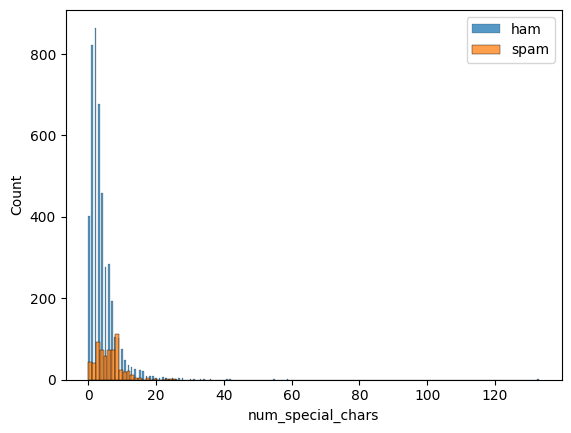

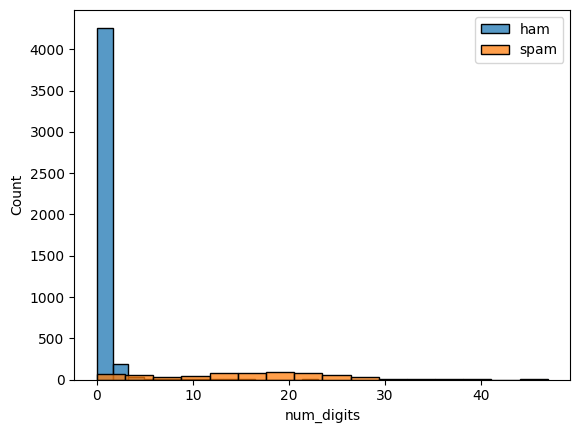

In [ ]:
for i in ['num_words',	'num_sent'	,'char','num_special_chars','num_digits']:
  sns.kdeplot(df[df['v1']==0][i],label='ham',fill=True)
  sns.kdeplot(df[df['v1']==1][i],label='spam',fill=True)

  plt.legend()
  plt.show()
for i in ['num_words',	'num_sent'	,'char','num_special_chars','num_digits']:

  sns.histplot(df[df['v1']==0][i],label='ham',fill=True)
  sns.histplot(df[df['v1']==1][i],label='spam',fill=True)
  plt.legend()
  plt.show()

NUMBER OF WORDS,SENTENCE,DIGITS AND CHARACTERS ARE GREATER IN SPAM AS COMPARED TO HAM

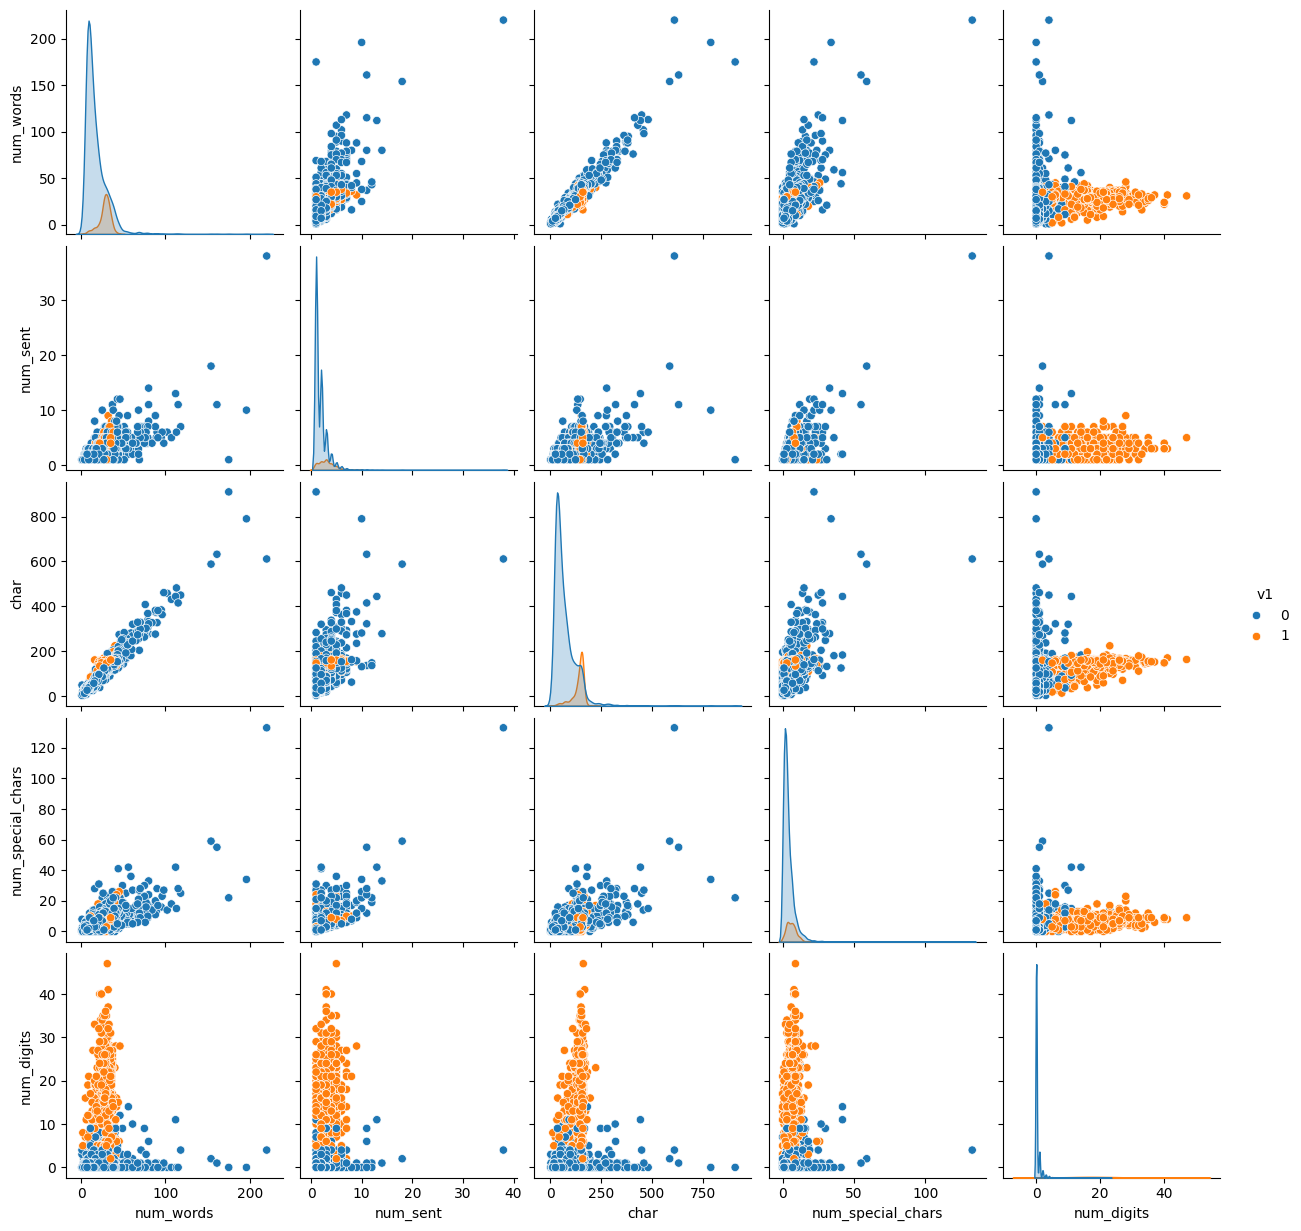

In [ ]:
sns.pairplot(
    df[['num_words',	'num_sent'	,'char','num_special_chars','num_digits','v1']],hue='v1'

)
plt.show()

<Axes: >

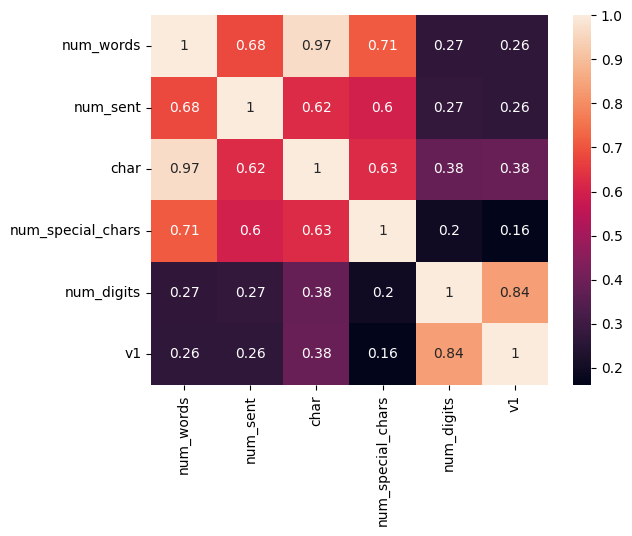

In [ ]:
sns.heatmap(df[['num_words',	'num_sent'	,'char','num_special_chars','num_digits','v1']].corr(),annot=True)

number of digits ar eexceptionally high in spam messages

**TEXT** **PREPROCESSING**


*   LOWER CASE



*   CLEANING MORE URLS AND PHONE NUMBER


*   NOT REMOVING SPECIAL CHARACTER THEY CAN COME HANDY





*   REMOVE STOP WORDS AND PUNCTATION



*   TOKENIZATION


*   STEMMING



In [ ]:
df.head()

,v1,v2,char,num_digits,num_special_chars,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,0,9,24,2
1,0,Ok lar... Joking wif u oni...,29,0,6,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,25,6,37,2
3,0,U dun say so early hor... U c already then say...,49,0,6,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,0,2,15,1


In [ ]:
df['v2'] = df['v2'].str.lower()

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

df['tokens'] = df['v2'].apply(nltk.word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

df['tokens'] = df['tokens'].apply(
    lambda tokens: [ps.stem(word) for word in tokens]
)

In [ ]:
df['clean_text'] = df['tokens'].apply(
    lambda x: ' '.join(x)
)

In [ ]:
import re

def clean_text(text):
    text = text.lower()

    # URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)

    # Phone numbers
    text = re.sub(r'\b\d{7,15}\b', ' PHONE ', text)

    # Extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df['clean_text'] = df['clean_text'].apply(clean_text)

In [ ]:
df.head()

,v1,v2,char,num_digits,num_special_chars,num_words,num_sent,tokens,clean_text
0,0,"go until jurong point, crazy.. available only ...",111,0,9,24,2,"[go, jurong, point, ,, crazi, .., avail, bugi,...","go jurong point , crazi .. avail bugi n great ..."
1,0,ok lar... joking wif u oni...,29,0,6,8,2,"[ok, lar, ..., joke, wif, u, oni, ...]",ok lar ... joke wif u oni ...
2,1,free entry in 2 a wkly comp to win fa cup fina...,155,25,6,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin...",free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say so early hor... u c already then say...,49,0,6,13,1,"[u, dun, say, earli, hor, ..., u, c, alreadi, ...",u dun say earli hor ... u c alreadi say ...
4,0,"nah i don't think he goes to usf, he lives aro...",61,0,2,15,1,"[nah, n't, think, goe, usf, ,, live, around, t...","nah n't think goe usf , live around though"


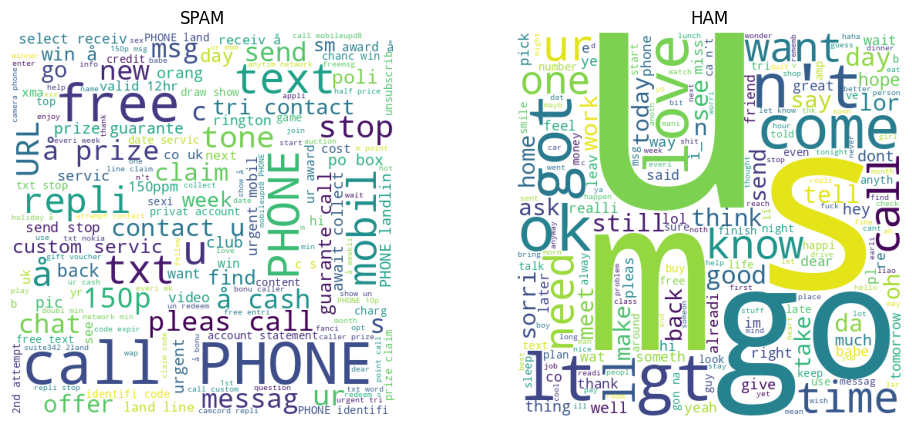

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_text = df[df['v1'] == 1]['clean_text'].str.cat(sep=' ')
ham_text = df[df['v1'] == 0]['clean_text'].str.cat(sep=' ')

spam_wc = WordCloud(
    width=500,
    height=500,
    min_font_size=10,
    background_color='white'
).generate(spam_text)

ham_wc = WordCloud(
    width=500,
    height=500,
    min_font_size=10,
    background_color='white'
).generate(ham_text)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(spam_wc)
plt.title('SPAM')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ham_wc)
plt.title('HAM')
plt.axis('off')

plt.show()

**MODEL MAKING**

|  | Vectorizer                       | ML Model                | Why                                                     |
| - | -------------------------------- | ----------------------- | ------------------------------------------------------- |
| 1 | **BoW**                          | Logistic Regression     | Simple baseline                                         |
| 2 | **TF-IDF**                       | Logistic Regression     | Strong traditional baseline                           |
| 3 | **TF-IDF**                       | Multinomial Naive Bayes | Very common for text classification                     |
| 4 | **TF-IDF**                       | Linear SVM              | Often very strong for text                              |
| 5 | **TF-IDF + engineered features** | Logistic Regression     | Tests whether your `num_words`, `num_digits`, etc. help |




In [ ]:
# BOW

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X1 = vectorizer.fit_transform(df['clean_text'])
y = df['v1']

print(X1.toarray())


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X2 = vectorizer.fit_transform(df['clean_text'])


print(X2.toarray())



[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)



In [ ]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression(penalty='l2', C=1.0,
                        tol=0.0001, fit_intercept=True,
                       intercept_scaling=1, class_weight=None,
                       random_state=42, solver='lbfgs', max_iter=1000, verbose=0, warm_start=False, n_jobs=-1)

**BOW ON LOG REG**

In [ ]:
cross_val_results = cross_val_score(clf, X1, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-Validation Results (Accuracy):
  Fold 1: 97.97%
  Fold 2: 97.68%
  Fold 3: 98.45%
  Fold 4: 98.36%
  Fold 5: 98.26%
Mean Accuracy: 98.14%
Accuracy : 0.9796905222437138
Precision: 0.984375
Recall   : 0.8689655172413793
F1 Score : 0.9230769230769231
ROC-AUC  : 0.9966952406811217

Confusion Matrix:
[[887   2]
 [ 19 126]]


**TF IDF ON LOG REG**

In [ ]:
cross_val_results = cross_val_score(clf, X2, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-Validation Results (Accuracy):
  Fold 1: 95.84%
  Fold 2: 95.36%
  Fold 3: 95.45%
  Fold 4: 95.84%
  Fold 5: 95.93%
Mean Accuracy: 95.69%
Accuracy : 0.9584139264990329
Precision: 0.9636363636363636
Recall   : 0.7310344827586207
F1 Score : 0.8313725490196079
ROC-AUC  : 0.9922345913657344

Confusion Matrix:
[[885   4]
 [ 39 106]]


**LOG REG WITH TF IDF AND MULTIPLE FEAURES**

In [ ]:
from scipy.sparse import hstack
X_extra = df[
    ['num_words', 'num_sent', 'char',
     'num_special_chars', 'num_digits']
].values

X_final1 = hstack([X2, X_extra])

In [ ]:
cross_val_results = cross_val_score(clf, X2, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')

X_train, X_test, y_train, y_test = train_test_split(X_final1, y, test_size=0.2, random_state=42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-Validation Results (Accuracy):
  Fold 1: 95.84%
  Fold 2: 95.36%
  Fold 3: 95.45%
  Fold 4: 95.84%
  Fold 5: 95.93%
Mean Accuracy: 95.69%
Accuracy : 0.9787234042553191
Precision: 0.984251968503937
Recall   : 0.8620689655172413
F1 Score : 0.9191176470588235
ROC-AUC  : 0.9902408750630309

Confusion Matrix:
[[887   2]
 [ 20 125]]


**LOG REG WITH MULTIPLE FEATUES AND BOW**

In [ ]:
from scipy.sparse import hstack
X_extra = df[
    ['num_words', 'num_sent', 'char',
     'num_special_chars', 'num_digits']
].values

X_final2 = hstack([X1, X_extra])

In [ ]:
cross_val_results = cross_val_score(clf, X2, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')

X_train, X_test, y_train, y_test = train_test_split(X_final2, y, test_size=0.2, random_state=42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-Validation Results (Accuracy):
  Fold 1: 95.84%
  Fold 2: 95.36%
  Fold 3: 95.45%
  Fold 4: 95.84%
  Fold 5: 95.93%
Mean Accuracy: 95.69%
Accuracy : 0.9845261121856866
Precision: 0.9849624060150376
Recall   : 0.903448275862069
F1 Score : 0.9424460431654677
ROC-AUC  : 0.99491873860595

Confusion Matrix:
[[887   2]
 [ 14 131]]


**SO FAR LOGISTIC REGRESSION WITH MUTIPLE FEATUES AND BOW HAS PERFORMED BETTER THAT OTHERS**

NAIVE BAYES

In [ ]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from scipy.sparse import issparse

models = {
    'MNB': MultinomialNB(),
    'GNB': GaussianNB(),
    'BNB': BernoulliNB()
}
from sklearn.model_selection import train_test_split

X1_train, X1_test, X2_train, X2_test, X_final1_train, X_final1_test, X_final2_train, X_final2_test, y_train, y_test = train_test_split(
    X1,
    X2,
    X_final1,
    X_final2,
    y,
    test_size=0.2,
    random_state=42,

)


datasets = {
    'BoW': (X1_train, X1_test),
    'TF-IDF': (X2_train, X2_test),
    'BoW + Features': (X_final1_train, X_final1_test),
    'TF-IDF + Features': (X_final2_train, X_final2_test)
}

for data_name, (X_train, X_test) in datasets.items():

    print("\n" + "="*70)
    print(f"DATASET: {data_name}")
    print("="*70)

    for model_name, model in models.items():

        # GaussianNB needs dense data
        if model_name == 'GNB':
            if issparse(X_train):
                X_train_model = X_train.toarray()
                X_test_model = X_test.toarray()
            else:
                X_train_model = X_train
                X_test_model = X_test
        else:
            X_train_model = X_train
            X_test_model = X_test

        # =====================================================
        # CROSS VALIDATION ON TRAINING DATA ONLY
        # =====================================================

        cv_scores = cross_val_score(
            model,
            X_train_model,
            y_train,
            cv=kf,
            scoring='accuracy'
        )

        # =====================================================
        # TRAIN ON COMPLETE TRAINING DATA
        # =====================================================

        model.fit(X_train_model, y_train)

        # =====================================================
        # TEST SET PREDICTION
        # =====================================================

        y_pred = model.predict(X_test_model)

        # Probability for ROC-AUC
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_model)[:, 1]
        else:
            y_prob = model.decision_function(X_test_model)

        # =====================================================
        # METRICS
        # =====================================================

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        cm = confusion_matrix(y_test, y_pred)

        # =====================================================
        # PRINT RESULTS
        # =====================================================

        print(f"\n{model_name}")

        print("\nCross-Validation Results (Accuracy):")

        for i, score in enumerate(cv_scores, 1):
            print(f"  Fold {i}: {score*100:.2f}%")

        print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}%")

        print("\nTest Set Results:")

        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print(f"ROC-AUC  : {roc_auc:.4f}")

        print("\nConfusion Matrix:")
        print(cm)


DATASET: BoW

MNB

Cross-Validation Results (Accuracy):
  Fold 1: 98.55%
  Fold 2: 98.55%
  Fold 3: 97.22%
  Fold 4: 98.07%
  Fold 5: 97.10%
Mean CV Accuracy: 97.90%

Test Set Results:
Accuracy : 0.9739
Precision: 0.8831
Recall   : 0.9379
F1 Score : 0.9097
ROC-AUC  : 0.9894

Confusion Matrix:
[[871  18]
 [  9 136]]

GNB

Cross-Validation Results (Accuracy):
  Fold 1: 88.03%
  Fold 2: 90.08%
  Fold 3: 87.67%
  Fold 4: 89.12%
  Fold 5: 86.82%
Mean CV Accuracy: 88.34%

Test Set Results:
Accuracy : 0.8781
Precision: 0.5404
Recall   : 0.8759
F1 Score : 0.6684
ROC-AUC  : 0.8772

Confusion Matrix:
[[781 108]
 [ 18 127]]

BNB

Cross-Validation Results (Accuracy):
  Fold 1: 97.58%
  Fold 2: 97.22%
  Fold 3: 97.10%
  Fold 4: 98.07%
  Fold 5: 96.01%
Mean CV Accuracy: 97.19%

Test Set Results:
Accuracy : 0.9720
Precision: 0.9603
Recall   : 0.8345
F1 Score : 0.8930
ROC-AUC  : 0.9959

Confusion Matrix:
[[884   5]
 [ 24 121]]

DATASET: TF-IDF

MNB

Cross-Validation Results (Accuracy):
  Fold 1: 95.8

| Features              | Model   |    CV Acc. |  Test Acc. |  Precision |     Recall |         F1 |    ROC-AUC |
| --------------------- | ------- | ---------: | ---------: | ---------: | ---------: | ---------: | ---------: |
| BoW                   | MNB     |     97.90% |     97.39% |     88.31% | **93.79%** |     90.97% |     98.94% |
| BoW                   | GNB     |     88.34% |     87.81% |     54.04% |     87.59% |     66.84% |     87.72% |
| BoW                   | BNB     |     97.19% |     97.20% |     96.03% |     83.45% |     89.30% | **99.59%** |
| TF-IDF                | MNB     |     95.45% |     96.81% |   **100%** |     77.24% |     87.16% |     98.88% |
| TF-IDF                | GNB     |     88.08% |     87.33% |     53.04% |     84.14% |     65.07% |     85.99% |
| TF-IDF                | BNB     |     97.19% |     97.20% |     96.03% |     83.45% |     89.30% | **99.59%** |
| BoW + Features        | MNB     |     96.98% |     96.42% |     92.86% |     80.69% |     86.35% |     91.87% |
| BoW + Features        | GNB     |     88.71% |     88.10% |     54.78% |     86.90% |     67.20% |     87.86% |
| BoW + Features        | BNB     |     97.53% |     97.29% |     95.35% |     84.83% |     89.78% |     99.58% |
| **TF-IDF + Features** | **MNB** | **98.14%** | **98.26%** | **96.35%** | **91.03%** | **93.62%** |     97.05% |
| TF-IDF + Features     | GNB     |     88.34% |     87.81% |     54.04% |     87.59% |     66.84% |     87.72% |
| TF-IDF + Features     | BNB     |     97.53% |     97.29% |     95.35% |     84.83% |     89.78% |     99.58% |


Best Naive Bayes model
TF-IDF + Features + MultinomialNB


CV Accuracy  = 98.14%
Test Accuracy = 98.26%


Precision     = 96.35%
Recall        = 91.03%
F1            = 93.62%
ROC-AUC       = 97.05%


It only missed:

13 spam messages

and incorrectly classified:

5 legitimate messages as spam.

In [204]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# CROSS VALIDATION ON TRAINING DATA
# ==========================================

cross_val_results = cross_val_score(
    clf,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy'
)

print("Cross-Validation Results (Accuracy):")

for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f"Mean CV Accuracy: {cross_val_results.mean() * 100:.2f}%")

# ==========================================
# TRAIN FINAL MODEL
# ==========================================

clf.fit(X_train, y_train)

# ==========================================
# TEST SET
# ==========================================

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# ==========================================
# METRICS
# ==========================================

print("\nTest Set Results:")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

# ==========================================
# CONFUSION MATRIX
# ==========================================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Cross-Validation Results (Accuracy):
  Fold 1: 98.79%
  Fold 2: 98.19%
  Fold 3: 98.31%
  Fold 4: 98.31%
  Fold 5: 98.19%
Mean CV Accuracy: 98.36%

Test Set Results:
Accuracy : 0.9874274661508704
Precision: 0.9836065573770492
Recall   : 0.916030534351145
F1 Score : 0.9486166007905138
ROC-AUC  : 0.994395272754939

Confusion Matrix:
[[901   2]
 [ 11 120]]


**HYPERPARAMETER TUNING ON LOG REG**

In [205]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=kf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV F1:")
print(grid.best_score_)



Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'C': 100, 'class_weight': None, 'solver': 'liblinear'}

Best CV F1:
0.9479364993212851


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


In [206]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Final Tuned Model Results:")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Final Tuned Model Results:
Accuracy : 0.988394584139265
Precision: 0.983739837398374
Recall   : 0.9236641221374046
F1 Score : 0.952755905511811
ROC-AUC  : 0.9937697074214028

Confusion Matrix:
[[901   2]
 [ 10 121]]


| Metric    | Original LR |   Tuned LR | Improvement |
| --------- | ----------: | ---------: | ----------: |
| Accuracy  |      98.74% | **98.84%** |      +0.10% |
| Precision |      98.36% | **98.37%** |      +0.01% |
| Recall    |      91.60% | **92.37%** |      +0.77% |
| F1        |      94.86% | **95.28%** |      +0.42% |
| ROC-AUC   |      99.44% |     99.38% |      -0.06% |
